# Описание датасета: Medical Cost Personal Datasets

## Общее описание

- Источник: https://www.kaggle.com/datasets/mirichoi0218/insurance
- Размер: (1338,7)
- Признаков: 7 (4 числовых, 3 - категориальных)
- Целевая переменная: charges (числовой тип) - медицинские расходы, выставленные к оплате в рамках мед страховки 
- Задача: Регрессия, прогнозирование стоимости страховки
- Типы данных: int64 (age, children), float64 (bmi, charges), str-категории (sex, smoker, region)

---

## Целевая переменная 

- charges: числовой тип. Признак указывает на то, сколько человек имеет расходов по медицинской страховку


---
## Признаки


| Признак  | Тип данных | Описание                                                                                                                                                                                               | Значения                     |
| -------- | ---------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ | ---------------------------- |
| age      | int64      | Возраст застрахованного лица                                                                                                                                                                           |                              |
| sex      | str        | Пол застрахованного лица                                                                                                                                                                               | 2 значения:<br>female / male |
| bmi      | float64    | индекс массы тела (ИМТ) — показатель, характеризующий соотношение веса и роста; объективный индекс массы тела (кг/м²), рассчитываемый как отношение веса к квадрату роста (в идеале — от 18,5 до 24,9) |                              |
| children | int64      | Количество детей, охваченных медицинской страховкой / количество иждивенцев                                                                                                                            | 6 возможных значений         |
| smoker   | str        | Курит ли застрахованное лицо                                                                                                                                                                           | 2 значения:<br>yes / no                     |
| region   | str        | Регион проживания застрахованного лица в США (северо-восток, юго-восток, юго-запад, северо-запад)                                                                                                      | 4 значения:<br>northeast / northwest / southeast / southwest |
| charges  | float64    | Индивидуальные медицинские расходы, выставленные к оплате в рамках медицинской страховки                                                                                                               |                              |

In [ ]:
import pandas as pd  
import seaborn as sns  
import matplotlib.pyplot as plt  
import numpy as np  

# Посмотрим на данные

In [66]:
# Функция для ознакомления с данными

def describe_feat(df, num_cols, cat_cols):
    print(f"{'№':>3} {'НАЗВАНИЕ':<25} {'ЧИСЛОВ.':<8} {'КАТЕГОР.':<8} {'ЧИСЛО ЗНАЧЕНИЙ':<17} {'ТИП КОЛОНКИ':<12} {'ЗНАЧЕНИЯ':<40}")
    print("-"*120)

    for idx, col in enumerate(df.columns):
        
        if col in num_cols:
            is_numeric = '+'
        else:
            is_numeric = ''

        if col in cat_cols:
            is_categorical = '+'
        else:
            is_categorical = ''
            
        unique_vals = df[col].unique()
        n_unique = len(unique_vals)
        col_type = df[col].dtype  

        if n_unique > 5:
            unique_display = list(unique_vals[:5]) + ["..."]
        else:
            unique_display = list(unique_vals)
        print(f"{idx:>3} {col:<25} {is_numeric:<8} {is_categorical:<8} {n_unique:<17} {str(col_type):<12} {str(unique_display):<40}")

In [67]:
df = pd.read_csv('data/insurance.csv')

In [68]:
print(f'Число признаков: {df.shape[1]}')
print(f'Число наблюдений: {df.shape[0]}')
print('---' * 50)

df.head()

Число признаков: 7
Число наблюдений: 1338
------------------------------------------------------------------------------------------------------------------------------------------------------


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [69]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [70]:
NUM_COLS = df.select_dtypes(include=['int64', 'float64']).columns
CAT_COLS = df.select_dtypes(include=['str']).columns

print("Число числовых признаков:", len(NUM_COLS))
print("Имена числовых признаков:")
print(NUM_COLS)

print("\nЧисло категориальных признаков:", len(CAT_COLS))
print("Имена категориальных признаков:")
print(CAT_COLS)


print(f'\nВсего признаков: {len(NUM_COLS) + len(CAT_COLS)}')

Число числовых признаков: 4
Имена числовых признаков:
Index(['age', 'bmi', 'children', 'charges'], dtype='str')

Число категориальных признаков: 3
Имена категориальных признаков:
Index(['sex', 'smoker', 'region'], dtype='str')

Всего признаков: 7


In [71]:
describe_feat(df, NUM_COLS, CAT_COLS)

  № НАЗВАНИЕ                  ЧИСЛОВ.  КАТЕГОР. ЧИСЛО ЗНАЧЕНИЙ    ТИП КОЛОНКИ  ЗНАЧЕНИЯ                                
------------------------------------------------------------------------------------------------------------------------
  0 age                       +                 47                int64        [np.int64(19), np.int64(18), np.int64(28), np.int64(33), np.int64(32), '...']
  1 sex                                +        2                 str          ['female', 'male']                      
  2 bmi                       +                 548               float64      [np.float64(27.9), np.float64(33.77), np.float64(33.0), np.float64(22.705), np.float64(28.88), '...']
  3 children                  +                 6                 int64        [np.int64(0), np.int64(1), np.int64(3), np.int64(2), np.int64(5), '...']
  4 smoker                             +        2                 str          ['yes', 'no']                           
  5 region                   

In [ ]:
# Проверка на пропуски
print(f'Пропуски в датасете:\n{df.isnull().sum().sum()}')

# Проверка на дубликаты
print(f'Дубликаты в датасете:\n{df.duplicated().sum()}')

Пропуски в датасете:
0
Дубликаты в датасете:
1


После ознакомления с данными уже видим, что:
1. Признаки имеют 3 типа данных: str, int64, float64
2. 4 признака числовые, 3 - категориальные
3. Пропусков в датасете нет, а дубликат найден был один. Рассмотрим его подробнее дальше
4. В столбце `children` видим всего 6 значений, а это значит, что хоть и признак числовой, но также является порядковым


In [73]:
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [74]:
df[df['charges'] == 1639.5631]

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [75]:
# Расчет процента дубликатов: 1 строка = 0.075% — безопасно удалять без потери структуры
duplicate_percentage = df.duplicated().mean() * 100

print(f'Процент дубликатов: {duplicate_percentage.round(3)}%')

Процент дубликатов: 0.075%


Видим, что дублирующая строка полностью совпадает с оригинальной. Также дубликат всего 1 в датасете, а это 0.075% от всего датасета -> можем удалить

In [ ]:
# Удалим дубликаты
df = df.drop_duplicates()

print(f'Дубликаты в датасете:\n{df.duplicated().sum()}')

Дубликаты в датасете:
0


In [77]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1337.0,39.222139,14.044333,18.0000,27.000,39.0000,51.00000,64.00000
bmi,1337.0,30.663452,6.100468,15.9600,26.290,30.4000,34.70000,53.13000
children,1337.0,1.095737,1.205571,0.0000,0.000,1.0000,2.00000,5.00000
charges,1337.0,13279.121487,12110.359656,1121.8739,4746.344,9386.1613,16657.71745,63770.42801


In [ ]:
# Посмотрим на целевую переменную подробнее

mean_val = df['charges'].mean()
median_val = df['charges'].median()

print(f'Mean = {mean_val}\nMedian = {median_val}\nMax = {df['charges'].max()}')
print(f'Коэффициент эксцесса = {df['charges'].kurt()}')
print(f'Коэффициент асимметрии = {df['charges'].skew()}')

Mean = 13279.121486655948
Median = 9386.1613
Max = 63770.42801
Коэффициент эксцесса = 1.6042206849514362
Коэффициент асимметрии = 1.5153909108403483


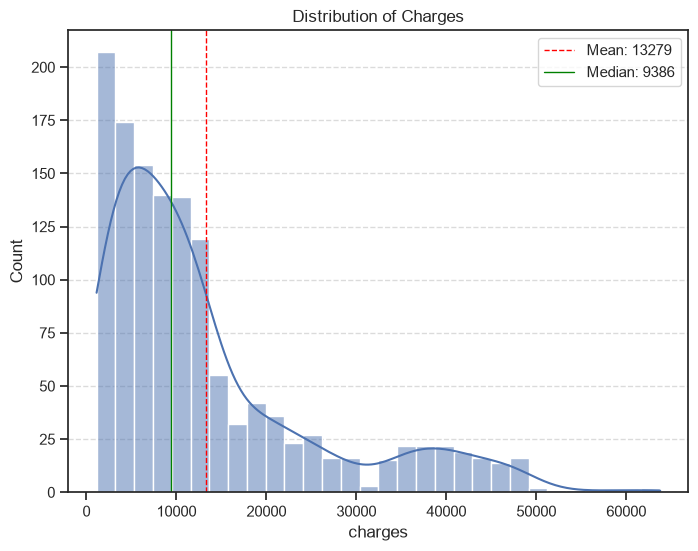

In [79]:
# Рассмотрим распределение целевой переменной

sns.set_theme(style="ticks")

plt.figure(figsize=(8,6))
sns.histplot(df['charges'], kde=True, bins=30)

plt.axvline(mean_val, color='red', linestyle='--', linewidth=1, label=f'Mean: {mean_val:.0f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=1, label=f'Median: {median_val:.0f}')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()

plt.title('Distribution of Charges')

plt.savefig('img/distribution_of_charges.png', format='png', dpi=200, bbox_inches='tight')




Видим перекошенное распределение целевой переменной вправо. У распределения длинный хвост из малого количества больших значений, а большинство данных сгруппированы слева -> kurtosis = 1.6

Коэффициент асимметрии равен 1.515 -> также подтверждает наше смещение

Медиана меньше среднего примерно на 4000

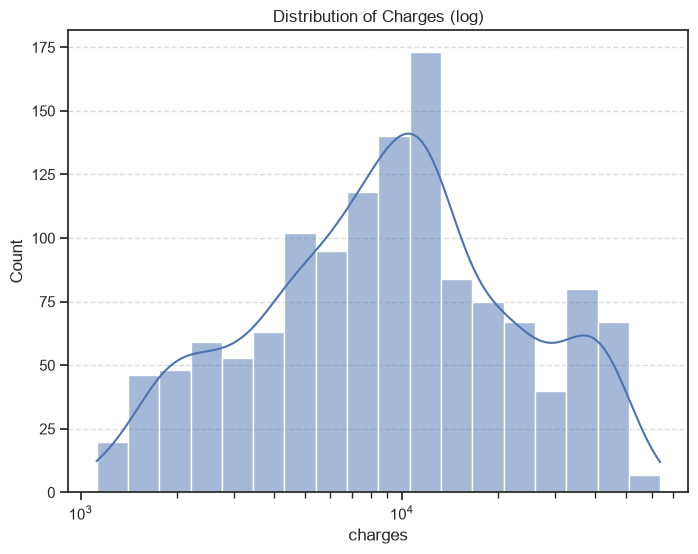

In [80]:
plt.figure(figsize=(8,6))
sns.histplot(df['charges'], kde=True, log_scale=True)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.title('Distribution of Charges (log)')

plt.savefig('img/distribution_of_charges_log.png', format='png', dpi=200, bbox_inches='tight')



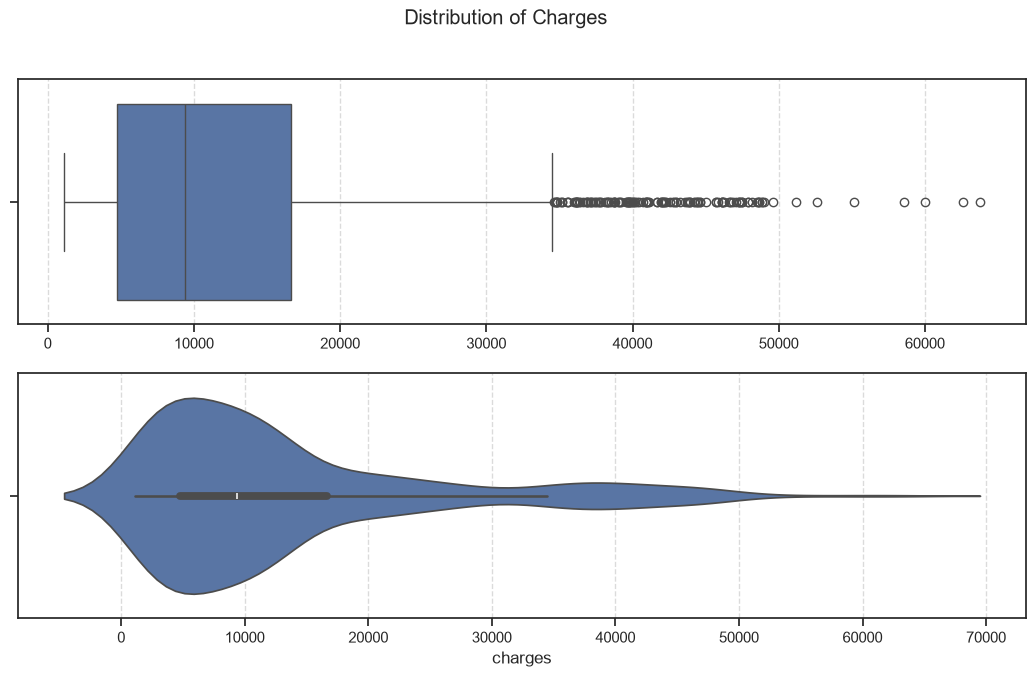

In [81]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7))

sns.boxplot(x=df['charges'], ax=axes[0])
axes[0].set_xlabel('')
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

sns.violinplot(x=df['charges'], ax=axes[1])
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

plt.suptitle('Distribution of Charges')

plt.savefig('img/box_violin_charges.png', format='png', dpi=200, bbox_inches='tight')


In [ ]:
# Топ 10 самых дорогих наблюдений по стоимости страховки

df.nlargest(10, 'charges')

,age,sex,bmi,children,smoker,region,charges
543,54,female,47.410,0,yes,southeast,63770.42801
1300,45,male,30.360,0,yes,southeast,62592.87309
1230,52,male,34.485,3,yes,northwest,60021.39897
577,31,female,38.095,1,yes,northeast,58571.07448
819,33,female,35.530,0,yes,northwest,55135.40209
1146,60,male,32.800,0,yes,southwest,52590.82939
34,28,male,36.400,1,yes,southwest,51194.55914
1241,64,male,36.960,2,yes,southeast,49577.66240
1062,59,male,41.140,1,yes,southeast,48970.24760
488,44,female,38.060,0,yes,southeast,48885.13561


In [88]:
# Зафиксируем размер датасета после первичной обработки и сохраним 

print(df.shape)

df.to_csv('data/cleaned_data.csv', index=False)

(1337, 7)


## Итог после ознакомления с данными

При первичном ознакомлении с данными было выяснено: 
1. Датасет Medical Cost Personal Datasets — 1338 записей, 7 полей: возраст, пол, индекс массы тела, число детей, статус курения, регион и итоговая сумма расходов `charges`, которую и будем прогнозировать
2. Пропущенных значений нет. При проверке найдена всего одна полностью дублирующаяся строка — 0.075% выборки, записи 195 и 581 идентичны. Дубликат был удален, итоговая очищенная выборка — 1337 записей, зафиксирована в файле `data/cleaned_data.csv`
3. Вывод по целевой переменной `charges`: 
    - распределение смещено вправо: средняя сумма 13279 при медиане 9386, стандартное отклонение 12110, максимум превышает 63000
    - коэффициент асимметрии 1.51 подтверждает длинный хвост дорогих случаев
    - срез топ-10 самых затратных полисов показывает, что это исключительно курящие клиенты